## Quick glance at roadway counts

In [2]:
# import libraries
import pandas as pd
import geopandas as gpd
import numpy as np

# read data
seattle_geo_raw = gpd.read_file("seattle-routes-data-for-all-vehicles-in-all-time.geojson")
spokane_geo_raw = gpd.read_file("spokane-routes-data-for-all-vehicles-in-all-time.geojson")

In [3]:
seattle_geo_raw.head()

,name,geometryId,percentage,displayCount,count,geometry
0,Northwest 71st Street,61dfb2f82b45b820221bfdad13f00e79,0.0,< 100,NaN,"LINESTRING (-122.393 47.68027, -122.3957 47.68..."
1,,deebba50276b46fcaa286f5ea0f9823f,0.0,< 100,NaN,"LINESTRING (-122.34196 47.6957, -122.34197 47...."
2,,5cbac22e094a6bc7faddeb3ff8ce46ad,0.0,< 100,NaN,"LINESTRING (-122.32239 47.58216, -122.32347 47..."
3,,e356ba9cff9c049d64787fa7c85c9517,0.0,< 100,NaN,"LINESTRING (-122.40021 47.64194, -122.40012 47..."
4,,75df6173f1495dfbd4f2af33c030673d,0.0,< 100,NaN,"LINESTRING (-122.32461 47.63677, -122.32461 47..."


In [ ]:
# deleted columns to ensure that the file size was small enought to load in streamlit
colums_to_delete = ["displayCount", "percentage", "geometryId"]
seattle_geo_raw.drop(columns=colums_to_delete).to_file("seattle_micro_streets.geojson", driver='GeoJSON')
spokane_geo_raw.drop(columns=colums_to_delete).to_file("spokane_micro_streets.geojson", driver='GeoJSON')

<Axes: >

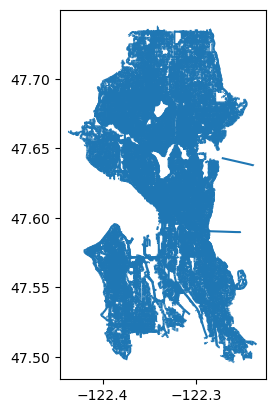

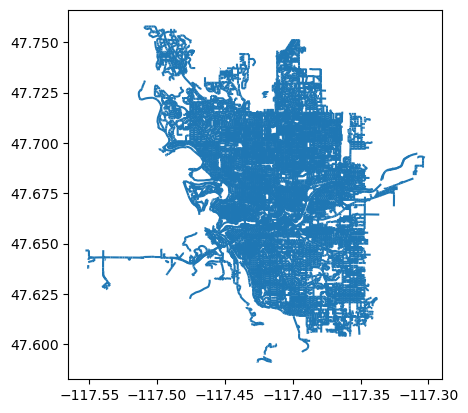

In [3]:
seattle_geo_raw.plot()
spokane_geo_raw.plot()

<Axes: >

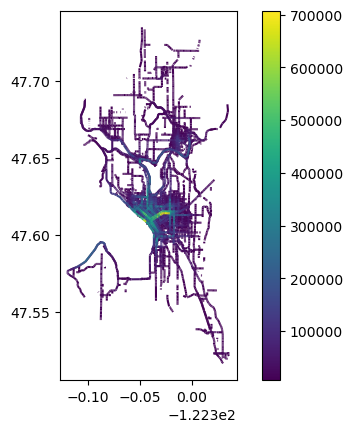

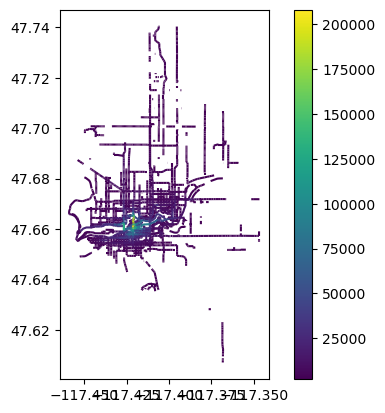

In [7]:
# drop null count rows
seattle_geo = seattle_geo_raw.dropna(subset=["count"])
spokane_geo = spokane_geo_raw.dropna(subset=["count"])

# plot count data with a min value
seattle_min_count = seattle_geo["count"].max()/100
seattle_geo[seattle_geo["count"]>=seattle_min_count].plot(column="count", legend=True,)

spokane_min_count = spokane_geo["count"].max()/100
spokane_geo[spokane_geo["count"]>=spokane_min_count].plot(column="count", legend=True,)

## The Census Tract Data

In [1]:
import pandas as pd
import geopandas as gpd

# read data
tract_data_df_raw = pd.read_csv("King_SpokaneCounty_ACS2024_Raw.csv", )
track_geom_raw = gpd.read_file("tl_2024_53_tract_geo.json")

# fix up data to be able to merge
track_geom_raw["GEOID"] = track_geom_raw["GEOID"].astype(int)

tract_data_df_raw.rename(columns={"FIPS": "GEOID"}, inplace=True)
tract_data_df_raw = tract_data_df_raw.iloc[1:]
tract_data_df_raw["GEOID"] = tract_data_df_raw["GEOID"].astype(int)

In [2]:
# merge data
track_data_geom = track_geom_raw.merge(tract_data_df_raw, left_on="GEOID", right_on="GEOID")

# drop extraneous columns
track_data_geom.drop(columns=["STATEFP", "GEOIDFQ", "NAMELSAD", "Area (Land)", "Area (Water)",
                              "Qualified Area Name", "GeoLevel"], inplace=True)

# rename columns
track_data_geom.columns = [# County ID, "033" is king county, "063" is spokane county
                          "COUNTYFP",
                          # other stuff
                          "TRACTCE", "GEOID", "TRACT", "MTFCC", "FUNCSTAT",
                          # Area that is land and water
                          "AREA_LAND", "AREA_WATER",
                          # more other stuff
                          "INTPTLAT", "INTPTLON", "geometry", "tract_name",
                          # total population and race breakdown
                          "TOTAL_POP", "POP_WHITE", "POP_BLACK",
                          "POP_NATIVE", "POP_ASAIN", "POP_HAWAIIAN",
                          "POP_OTHER", "POP_TWO_OR_MORE",
                          # median household income
                          "MED_HH_INCOME",
                          # The population 25 and over with different education levels
                          "TOTAL_POP_25", "POP_25_no_highschool", "POP_25_highschool",
                          "POP_25_some_college", "POP_25_bach", "POP_25_mast",
                           "POP_25_prof_degree", "POP_25_doct"]

# make some columns numeric
col_names = track_data_geom.columns[12:28]
track_data_geom[col_names] = track_data_geom[col_names].apply(pd.to_numeric, errors='coerce')
col_names = track_data_geom.columns[6:7]
track_data_geom[col_names] = track_data_geom[col_names].apply(pd.to_numeric, errors='coerce')

track_data_geom["POP_DENSITY"] = track_data_geom["TOTAL_POP"] / track_data_geom["AREA_LAND"]

In [4]:
track_data_geom.to_file("census_data.geojson", driver='GeoJSON')

<Axes: >

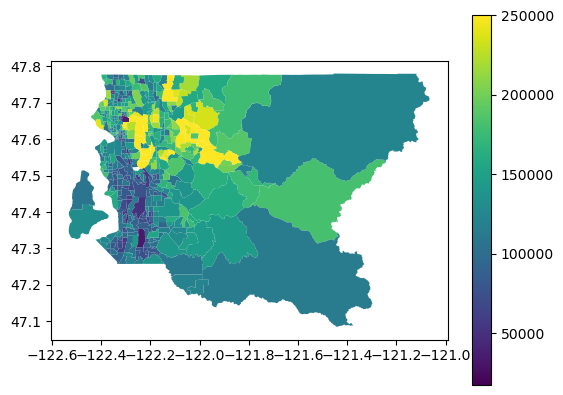

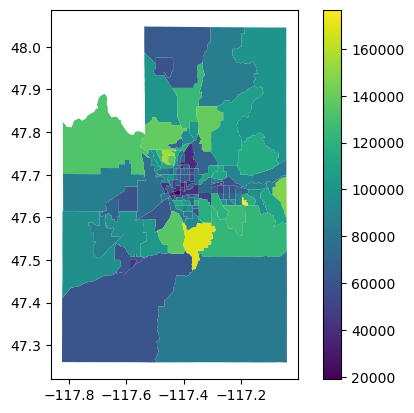

In [57]:
# plot county datas
track_data_geom[track_data_geom["COUNTYFP"] == "033"].plot(column= "MED_HH_INCOME", legend=True)
track_data_geom[track_data_geom["COUNTYFP"] == "063"].plot(column= "MED_HH_INCOME", legend=True)

## Spacial ANALYSIS

In [8]:
# Get king county tracts that intersect with the seattle streets
seattle_streets_union = seattle_geo[seattle_geo["count"] > 0].union_all()
king_county_tracts = track_data_geom[track_data_geom["COUNTYFP"] == "033"]
selected_seattle_areas = king_county_tracts[king_county_tracts.intersects(seattle_streets_union)]

# ------> MAY TAKE A HOT SECOND TO RUN: ~5 - 5.5 mins for me

c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

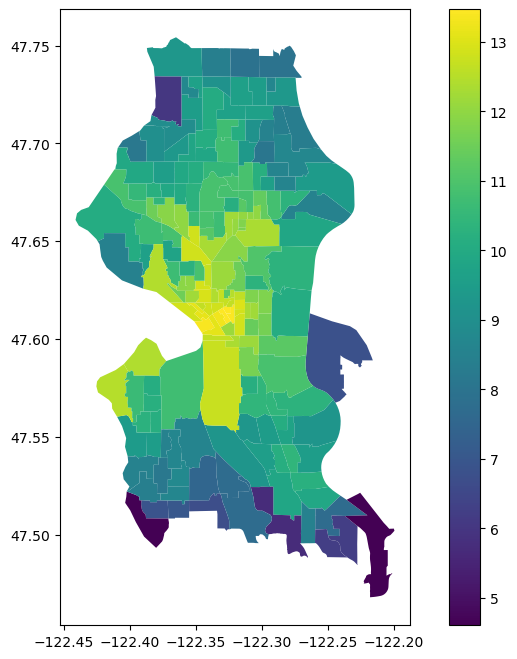

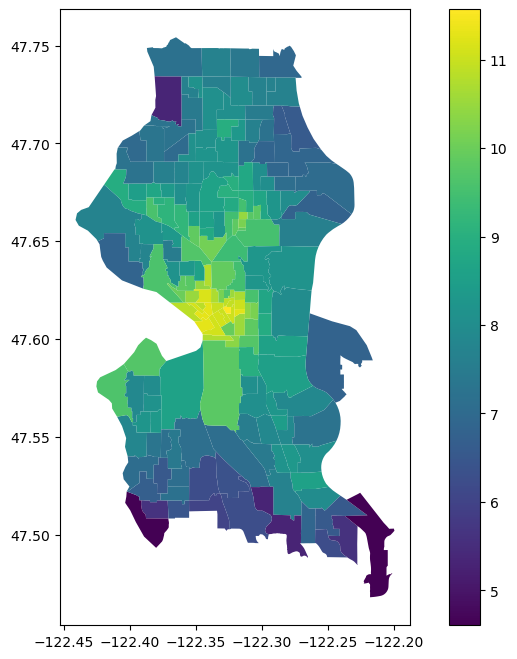

In [45]:
#  get max and average count of streets in each tract
selected_seattle_areas["max_count"] = selected_seattle_areas.apply(lambda row: seattle_geo[seattle_geo.intersects(row.geometry)]["count"].max(), axis=1)
selected_seattle_areas["avg_count"] = selected_seattle_areas.apply(lambda row: seattle_geo[seattle_geo.intersects(row.geometry)]["count"].mean(), axis=1)

selected_seattle_areas["log_max_count"] = np.where(selected_seattle_areas["max_count"] > 0, np.log(selected_seattle_areas["max_count"]), np.nan)
selected_seattle_areas["log_avg_count"] = np.where(selected_seattle_areas["avg_count"] > 0, np.log(selected_seattle_areas["avg_count"]), np.nan)

# Plot result
selected_seattle_areas.plot(column = selected_seattle_areas["log_max_count"], figsize=(10, 8), legend=True)
selected_seattle_areas.plot(column = selected_seattle_areas["log_avg_count"], figsize=(10, 8), legend=True)

In [9]:
# Get king county tracts that intersect with the seattle streets
spokane_streets_union = spokane_geo[spokane_geo["count"] > 0].union_all()
spokane_county_tracts = track_data_geom[track_data_geom["COUNTYFP"] == "063"]
selected_spokane_areas = spokane_county_tracts[spokane_county_tracts.intersects(spokane_streets_union)]

c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

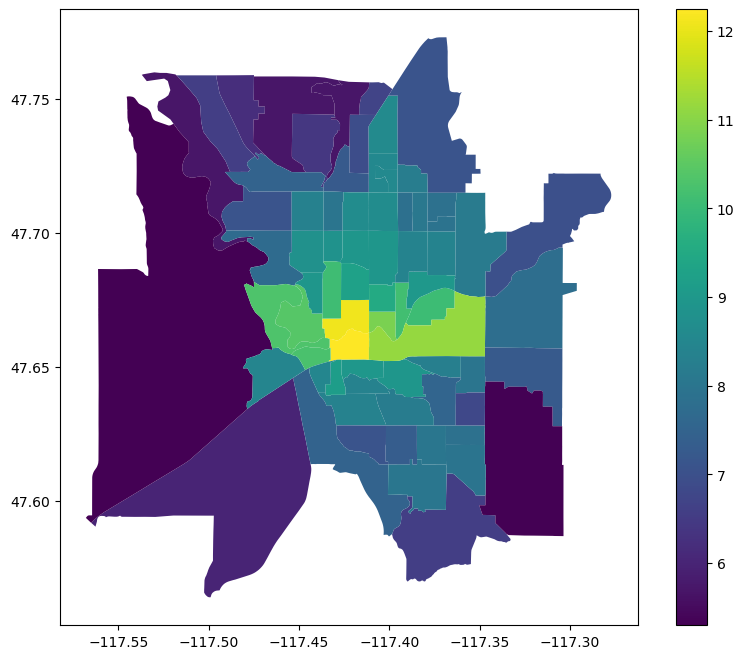

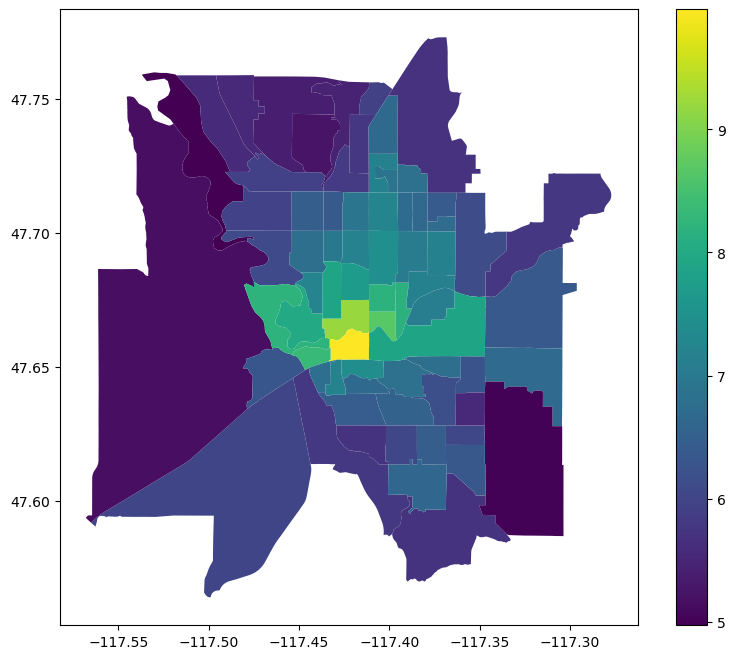

In [ ]:
#  get max and average count of streets in each tract
selected_spokane_areas["max_count"] = selected_spokane_areas.apply(lambda row: spokane_geo[spokane_geo.intersects(row.geometry)]["count"].max(), axis=1)
selected_spokane_areas["avg_count"] = selected_spokane_areas.apply(lambda row: spokane_geo[spokane_geo.intersects(row.geometry)]["count"].mean(), axis=1)


selected_spokane_areas["log_max_count"] = np.where(selected_spokane_areas["max_count"] > 0, np.log(selected_spokane_areas["max_count"]), np.nan)
selected_spokane_areas["log_avg_count"] = np.where(selected_spokane_areas["avg_count"] > 0, np.log(selected_spokane_areas["avg_count"]), np.nan)

# Plot result
selected_spokane_areas.plot(column = selected_spokane_areas["log_max_count"], figsize=(10, 8), legend=True)
selected_spokane_areas.plot(column = selected_spokane_areas["log_avg_count"], figsize=(10, 8), legend=True)

<Axes: >

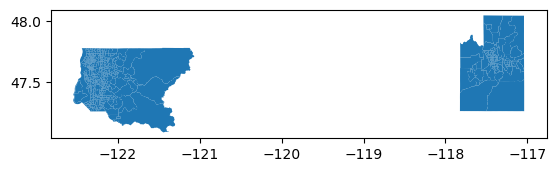

In [47]:
col = ["COUNTYFP", "TRACT", "max_count", "avg_count",  "log_max_count", "log_avg_count"]
a = track_data_geom.copy()
b = pd.concat([selected_spokane_areas[col], selected_seattle_areas[col]])
a = a.merge(b, on=("COUNTYFP", "TRACT"), how="left")
a.to_file("census_data.geojson", driver='GeoJSON')
a.plot()

In [50]:
g = gpd.read_file("census_data.geojson")

In [52]:
g["log_POP_DENSITY"] = np.where(g["POP_DENSITY"] > 0, np.log(g["POP_DENSITY"]), np.nan)
g.to_file("census_data.geojson", driver='GeoJSON')

# Grid Analysis

In [37]:
from shapely.geometry import box

def make_grid(total_bounds):
    minx, miny, maxx, maxy = total_bounds
    # degrees in lat/long
    cell_size = 0.005  
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            grid_cells.append(box(x, y, x+cell_size, y+cell_size))
            y += cell_size
        x += cell_size

    # turn into geo df
    grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=selected_seattle_areas.crs)

    # add id to grid
    grid["GRID_ID"] = grid.index + 1
    return grid.copy()

In [38]:
seattle_grid = make_grid(seattle_geo.total_bounds)

# filter the grid to only be the grid cells that ONLY intersects road OR completely within the seattle geo
filtered_seattle_grid = seattle_grid[seattle_grid.geometry.intersects(seattle_geo.union_all()) | seattle_grid.geometry.within(selected_seattle_areas.dissolve().geometry.iloc[0])]

# add max_count and avg_count data to the grid
filtered_seattle_grid["max_count"] = filtered_seattle_grid.apply(lambda row: seattle_geo[seattle_geo.intersects(row.geometry)]["count"].max(), axis=1)
filtered_seattle_grid["avg_count"] = filtered_seattle_grid.apply(lambda row: seattle_geo[seattle_geo.intersects(row.geometry)]["count"].mean(), axis=1)
filtered_seattle_grid = filtered_seattle_grid.fillna(0)

# calculate the vars for log version
filtered_seattle_grid["log_max_count"] = np.where(filtered_seattle_grid["max_count"] > 0, np.log(filtered_seattle_grid["max_count"]), np.nan)
filtered_seattle_grid["log_avg_count"] = np.where(filtered_seattle_grid["avg_count"] > 0, np.log(filtered_seattle_grid["avg_count"]), np.nan)


c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tarri\miniconda3\L

In [39]:
#SAME FOR SPOKANE
spokane_grid = make_grid(spokane_geo.total_bounds)

# filter the grid to only be the grid cells that ONLY intersects road OR completely within the seattle geo
filtered_spokane_grid = spokane_grid[spokane_grid.geometry.intersects(spokane_geo.union_all()) | spokane_grid.geometry.within(selected_spokane_areas.dissolve().geometry.iloc[0])]

# add max_count and avg_count data to the grid
filtered_spokane_grid["max_count"] = filtered_spokane_grid.apply(lambda row: spokane_geo[spokane_geo.intersects(row.geometry)]["count"].max(), axis=1)
filtered_spokane_grid["avg_count"] = filtered_spokane_grid.apply(lambda row: spokane_geo[spokane_geo.intersects(row.geometry)]["count"].mean(), axis=1)
filtered_spokane_grid = filtered_spokane_grid.fillna(0)

# calculate the vars for log version
filtered_spokane_grid["log_max_count"] = np.where(filtered_spokane_grid["max_count"] > 0, np.log(filtered_spokane_grid["max_count"]), np.nan)
filtered_spokane_grid["log_avg_count"] = np.where(filtered_spokane_grid["avg_count"] > 0, np.log(filtered_spokane_grid["avg_count"]), np.nan)

c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\tarri\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tarri\miniconda3\L

In [ ]:
def generate_area_weighted_variables(grid, census):
    # PREP geographies for data weighted by area

    # CRS for equal area projection in the US
    EQ_AREA = "EPSG:5070"
    #old_projection = filtered_seattle_grid.crs

    new_projected_grid = grid.to_crs(EQ_AREA)
    new_projected_census = census.to_crs(EQ_AREA)
    
    

    # fix invalid geometries (if any)
    for gdf in (new_projected_grid, selected_seattle_areas):
        invalid = ~gdf.is_valid
        if invalid.any():
            gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)



    # calculate the data weighted by area

    new_projected_grid["grid_area"] = new_projected_grid.geometry.area
    new_projected_census['tract_area'] = new_projected_census.geometry.area

    # intensive variables (rates/percentages/densities)
    # PUT THE VARIABLES DESIRED HERE
    intensive_vars = ["POP_DENSITY", 
                      "TOTAL_POP", "POP_WHITE", "POP_BLACK",
                      "POP_NATIVE", "POP_ASAIN", "POP_HAWAIIAN",
                      "POP_OTHER", "POP_TWO_OR_MORE",
                      "MED_HH_INCOME",
                      "TOTAL_POP_25", "POP_25_no_highschool", "POP_25_highschool",
                      "POP_25_some_college", "POP_25_bach", "POP_25_mast",
                      "POP_25_prof_degree", "POP_25_doct"]
    
    for v in intensive_vars:
        pd.to_numeric(census[v], errors='coerce')

    inter = gpd.overlay(
        new_projected_grid[["GRID_ID", "geometry"]],
        new_projected_census[["GEOID", "geometry"]+intensive_vars],
        how="intersection"
    )
    inter["int_area"] = inter.geometry.area
    
    for v in intensive_vars:
        inter[f'{v}_num'] = inter[v].astype(float) * inter['int_area']

    agg_intensive = inter.groupby('GRID_ID').agg(
        **{f'{v}_num_sum': (f'{v}_num', 'sum') for v in intensive_vars},
        area_sum=('int_area', 'sum')
    )

    # Compute the area-weighted means
    for v in intensive_vars:
        agg_intensive[f'{v}_aw'] = agg_intensive[f'{v}_num_sum'] / agg_intensive['area_sum']

    # Keep only the final AW columns
    aw_cols = [f'{v}_aw' for v in intensive_vars]
    agg_intensive = agg_intensive[aw_cols]


    # join it with the grid
    return grid.join(agg_intensive, on="GRID_ID", how="left").copy()


<Axes: >

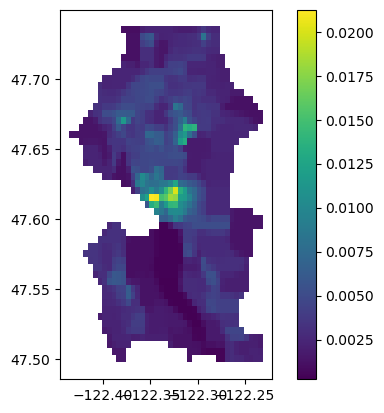

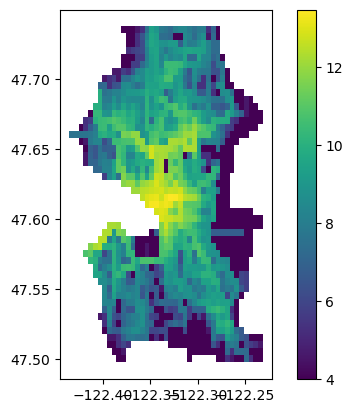

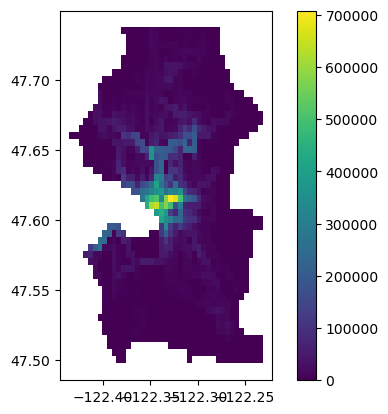

In [41]:
grid_seattle = generate_area_weighted_variables(filtered_seattle_grid, track_data_geom[track_data_geom.geometry.intersects(filtered_seattle_grid.dissolve().geometry.iloc[0])])
grid_seattle["log_POP_DENSITY_aw"] = np.where(grid_seattle["POP_DENSITY_aw"] > 0, np.log(grid_seattle["POP_DENSITY_aw"]), 0)

grid_seattle.plot(column="POP_DENSITY_aw", legend=True)
grid_seattle.fillna(4).plot(column="log_max_count", legend=True)
grid_seattle.plot(column="max_count", legend=True)

<Axes: >

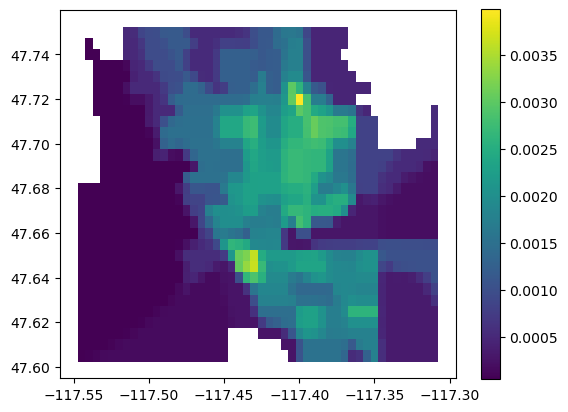

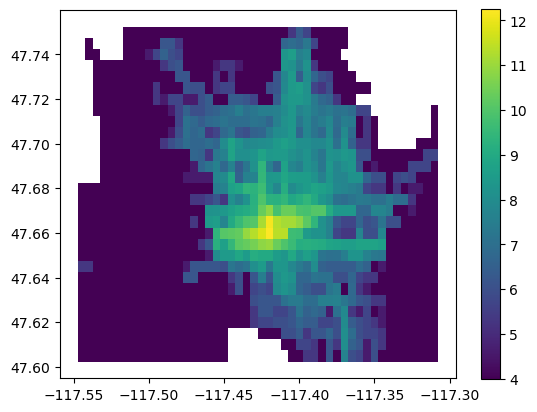

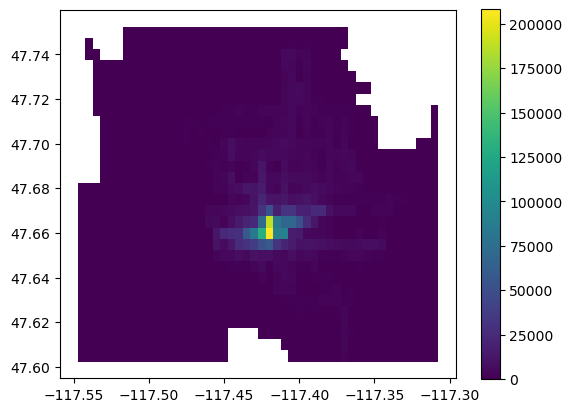

In [42]:
grid_spokane = generate_area_weighted_variables(filtered_spokane_grid, track_data_geom[track_data_geom.geometry.intersects(filtered_spokane_grid.dissolve().geometry.iloc[0])])
grid_spokane["log_POP_DENSITY_aw"] = np.where(grid_spokane["POP_DENSITY_aw"] > 0, np.log(grid_spokane["POP_DENSITY_aw"]), 0)

grid_spokane.plot(column="POP_DENSITY_aw", legend=True)
grid_spokane.fillna(4).plot(column="log_max_count", legend=True)
grid_spokane.plot(column="max_count", legend=True)

In [43]:
grid_seattle.columns

Index(['geometry', 'GRID_ID', 'max_count', 'avg_count', 'log_max_count',
       'log_avg_count', 'POP_DENSITY_aw', 'TOTAL_POP_aw', 'POP_WHITE_aw',
       'POP_BLACK_aw', 'POP_NATIVE_aw', 'POP_ASAIN_aw', 'POP_HAWAIIAN_aw',
       'POP_OTHER_aw', 'POP_TWO_OR_MORE_aw', 'MED_HH_INCOME_aw',
       'TOTAL_POP_25_aw', 'POP_25_no_highschool_aw', 'POP_25_highschool_aw',
       'POP_25_some_college_aw', 'POP_25_bach_aw', 'POP_25_mast_aw',
       'POP_25_prof_degree_aw', 'POP_25_doct_aw', 'log_POP_DENSITY_aw'],
      dtype='object')

In [44]:
grid_spokane.columns

Index(['geometry', 'GRID_ID', 'max_count', 'avg_count', 'log_max_count',
       'log_avg_count', 'POP_DENSITY_aw', 'TOTAL_POP_aw', 'POP_WHITE_aw',
       'POP_BLACK_aw', 'POP_NATIVE_aw', 'POP_ASAIN_aw', 'POP_HAWAIIAN_aw',
       'POP_OTHER_aw', 'POP_TWO_OR_MORE_aw', 'MED_HH_INCOME_aw',
       'TOTAL_POP_25_aw', 'POP_25_no_highschool_aw', 'POP_25_highschool_aw',
       'POP_25_some_college_aw', 'POP_25_bach_aw', 'POP_25_mast_aw',
       'POP_25_prof_degree_aw', 'POP_25_doct_aw', 'log_POP_DENSITY_aw'],
      dtype='object')

In [49]:
grid_seattle["COUNTYFP"] = "033"
grid_spokane["COUNTYFP"] = "063"
grid_data = pd.concat([grid_seattle, grid_spokane])
grid_data.to_file("grid_data.geojson", driver='GeoJSON')

## Regression Model

In [ ]:
# TODO regressional model for avg count and median household income and tot_pop/land_area ??
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, r2_score
import numpy as np

pd.set_option("display.max_columns", None)

# combine Seattle and Spokane data to be used in one regression 
selected_areas = pd.concat([selected_seattle_areas, selected_spokane_areas])

# Create population density variable and binary variable to indicate Seattle or Spokane
selected_areas["pop_den"] = selected_areas["TOT_POP"] / selected_areas["AREA_LAND"]
selected_areas["Seattle"] = [1 if x == "033" else 0 for x in selected_areas["COUNTYFP"]]
selected_areas["log_avg_count"] = np.log(selected_areas["avg_count"])

selected_areas = selected_areas.dropna(subset = ["pop_den", "MED_HH_INCOME"])

In [ ]:
selected_areas.shape

(260, 34)

In [ ]:
# Standard linear regression (non-ML)
# Use this to check ML model

y = selected_areas["avg_count"]
X = selected_areas[["Seattle", "pop_den", "MED_HH_INCOME"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              avg_count   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     73.50
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           2.54e-34
Time:                        23:30:05   Log-Likelihood:                -2835.8
No. Observations:                 260   AIC:                             5680.
Df Residuals:                     256   BIC:                             5694.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3141.7441   2285.007     -1.375      0.170   -7641.549    1358.061
Seattle        1884.2351   2406.874      0.783      0.434   -2855.558    6624.029
pop_den        2.212e+06   1.74e+05     12.744      0.000    1.87e+06    2.55e+06
MED_HH_INCOME     0.0092      0.021      0.447      0.655      -0.031       0.050
==============================================================================
Omnibus:                       95.719   Durbin-Watson:                   1.498
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1547.194
Skew:                           0.986   Prob(JB):                         0.00
Kurtosis:                      14.787   Cond. No.                     2.62e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.62e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Standard linear regression with log-transformed average counts (non-ML)
# Use this to check ML model

y = selected_areas["log_avg_count"]
X = selected_areas[["Seattle", "pop_den", "MED_HH_INCOME"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          log_avg_count   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     106.7
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           7.83e-45
Time:                        23:30:14   Log-Likelihood:                -382.35
No. Observations:                 260   AIC:                             772.7
Df Residuals:                     256   BIC:                             787.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.6597      0.182     36.540      0.000       6.301       7.019
Seattle           1.3737      0.192      7.156      0.000       0.996       1.752
pop_den         154.4021     13.847     11.151      0.000     127.134     181.670
MED_HH_INCOME -3.702e-06   1.64e-06     -2.260      0.025   -6.93e-06   -4.76e-07
==============================================================================
Omnibus:                       28.863   Durbin-Watson:                   1.324
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               82.249
Skew:                          -0.447   Prob(JB):                     1.38e-18
Kurtosis:                       5.606   Cond. No.                     2.62e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.62e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### ML

In [ ]:
#Get training, validation, and test sets

train = selected_areas.sample(frac = .7, random_state = 42)

remaining = selected_areas.drop(train.index)

val = remaining.sample(frac = .5, random_state = 42)
test = remaining.drop(val.index)


print("Train rows:", len(train))
print("Val rows  :", len(val))
print("Test rows :", len(test))

Train rows: 182
Val rows  : 39
Test rows : 39


In [ ]:
# get regression metrics

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    # MAPE (avoid division by zero by adding a tiny number)
    eps = 1e-6
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE(%)": mape}

In [ ]:
# linear regression on plain average counts

x_vars = ["pop_den", "Seattle", "MED_HH_INCOME"]

x_train = train[x_vars]
x_val = val[x_vars]
x_test = test[x_vars]

y_train = train["avg_count"]
y_val = val["avg_count"]
y_test = test["avg_count"]

lin = LinearRegression()
lin.fit(x_train, y_train)

pred_val = lin.predict(x_val)
pred_test = lin.predict(x_test)

lin_val = regression_metrics(y_val, pred_val)
lin_test = regression_metrics(y_test, pred_test)

pd.DataFrame([lin_val, lin_test], index=["LinearReg (Val)", "LinearReg (Test)"])

,MAE,RMSE,R2,MAPE(%)
LinearReg (Val),7393.258989,11424.449385,0.536652,241.125618
LinearReg (Test),6519.133120,10565.262318,0.626192,308.370057


In [ ]:
# linear regression on log-transformed average counts

x_vars = ["pop_den", "Seattle", "MED_HH_INCOME"]

x_train = train[x_vars]
x_val = val[x_vars]
x_test = test[x_vars]

y_log_train = train["log_avg_count"]
y_log_val = val["log_avg_count"]
y_log_test = test["log_avg_count"]

lin = LinearRegression()
lin.fit(x_train, y_log_train)

pred_val = lin.predict(x_val)
pred_test = lin.predict(x_test)

lin_log_val = regression_metrics(y_log_val, pred_val)
lin_log_test = regression_metrics(y_log_test, pred_test)

pd.DataFrame([lin_log_val, lin_log_test], index=["LinearReg (Val)", "LinearReg (Test)"])

,MAE,RMSE,R2,MAPE(%)
LinearReg (Val),0.774293,1.028565,0.581316,10.017198
LinearReg (Test),0.851519,1.078767,0.602886,12.196217


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Untransformed average counts random forest

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)
rf.fit(x_train, y_train)

rf_val_pred  = rf.predict(x_val)
rf_test_pred = rf.predict(x_test)

rf_val  = regression_metrics(y_val, rf_val_pred)
rf_test = regression_metrics(y_test, rf_test_pred)



# Log transformed average counts random forest
rf_log = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    n_jobs=-1
)

rf_log.fit(x_train, y_log_train)

rf_log_val_pred  = rf_log.predict(x_val)
rf_log_test_pred = rf_log.predict(x_test)

rf_log_val  = regression_metrics(y_log_val, rf_log_val_pred)
rf_log_test = regression_metrics(y_log_test, rf_log_test_pred)




#Compare models
compare_val = pd.DataFrame([lin_val, lin_log_val, rf_val, rf_log_val],
                           index=["LinearReg", "LogTransform", "RandomForest", "LogRandomForest"])
compare_test = pd.DataFrame([lin_test, lin_log_test, rf_test, rf_log_test],
                            index=["LinearReg", "LogTransform", "RandomForest", "LogRandomForest"])

print("Validation comparison (use this to choose a model):")
print(compare_val)

print("\nTest comparison (final report; do not tune based on this):")
print(compare_test)

Validation comparison (use this to choose a model):
                         MAE          RMSE        R2     MAPE(%)
LinearReg        7393.258989  11424.449385  0.536652  241.125618
LogTransform        0.774293      1.028565  0.581316   10.017198
RandomForest     5624.820505  11079.832670  0.564184  101.026990
LogRandomForest     0.638356      0.802661  0.745031    8.621781

Test comparison (final report; do not tune based on this):
                         MAE          RMSE        R2     MAPE(%)
LinearReg        6519.133120  10565.262318  0.626192  308.370057
LogTransform        0.851519      1.078767  0.602886   12.196217
RandomForest     6905.930367  13410.290684  0.397767  219.300235
LogRandomForest     0.815668      1.010300  0.651694   11.440880
